In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
# PostgreSQL connection configuration

DB_USER = "postgres"
DB_PASSWORD = "49377"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "customer_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("PostgreSQL connection configured successfully.")

PostgreSQL connection configured successfully.


In [3]:
# test the connection
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print("PostgreSQL connection successful.")

PostgreSQL connection successful.


In [4]:
# Check the RFM view.

query = """
SELECT *
FROM warehouse.v_customer_rfm
LIMIT 10;
"""

rfm_test = pd.read_sql(query, engine)

rfm_test

,customer_key,customer_id,country,last_purchase_date,recency,frequency,monetary
0,1,12346,United Kingdom,2011-01-18,326,12,77556.46
1,2,12347,Iceland,2011-12-07,3,8,4921.53
2,3,12348,Finland,2011-09-25,76,5,2019.40
3,4,12349,Italy,2011-11-21,19,4,4428.69
4,5,12350,Norway,2011-02-02,311,1,334.40
5,6,12351,Unspecified,2010-11-29,376,1,300.93
6,7,12352,Norway,2011-11-03,37,10,2849.84
7,8,12353,Bahrain,2011-05-19,205,2,406.76
8,9,12354,Spain,2011-04-21,233,1,1079.40
9,10,12355,Bahrain,2011-05-09,215,2,947.61


In [5]:
# Check the view structure.

print("Rows:", len(rfm_test))
print("\nColumns:")
print(rfm_test.columns.tolist())

Rows: 10

Columns:
['customer_key', 'customer_id', 'country', 'last_purchase_date', 'recency', 'frequency', 'monetary']


In [6]:
# Load the completed RFM Dataset from the PostgreSQL database.

query = """
SELECT *
FROM warehouse.v_customer_rfm;
"""

rfm = pd.read_sql(query, engine)

print("RFM dataset loaded successfully.")
print("Rows:", rfm.shape[0])
print("Columns:", rfm.shape[1])

query2 = """
SELECT monetary, recency, frequency
FROM warehouse.v_customer_rfm
LIMIT 10;
"""

rfm_sample = pd.read_sql(query2, engine)
print("Sample of RFM dataset:\n", rfm_sample)

RFM dataset loaded successfully.
Rows: 5878
Columns: 7
Sample of RFM dataset:
    monetary  recency  frequency
0  77556.46      326         12
1   4921.53        3          8
2   2019.40       76          5
3   4428.69       19          4
4    334.40      311          1
5    300.93      376          1
6   2849.84       37         10
7    406.76      205          2
8   1079.40      233          1
9    947.61      215          2


In [7]:
# Initial Inspection of the RFM dataset.

print(rfm.head())
print()

print(rfm.info())
print()

rfm.describe(include="all").T
print()

print("DataTypes:\n",rfm.dtypes)


   customer_key  customer_id         country last_purchase_date  recency  \
0             1        12346  United Kingdom         2011-01-18      326   
1             2        12347         Iceland         2011-12-07        3   
2             3        12348         Finland         2011-09-25       76   
3             4        12349           Italy         2011-11-21       19   
4             5        12350          Norway         2011-02-02      311   

   frequency  monetary  
0         12  77556.46  
1          8   4921.53  
2          5   2019.40  
3          4   4428.69  
4          1    334.40  

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_key        5878 non-null   int64  
 1   customer_id         5878 non-null   int64  
 2   country             5878 non-null   str    
 3   last_purchase_date  5878 non-null   object 
 4 

In [8]:
# Check for missing values in the RFM dataset.

missing = rfm.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)

No missing values found.


In [9]:
# Check for duplicate customer rows in the RFM dataset.
customer_id_col = "customer_id"

print("Total rows:", len(rfm))
print("Unique customers:", rfm[customer_id_col].nunique())
print("Duplicate customer rows:", rfm.duplicated(subset=[customer_id_col]).sum())

Total rows: 5878
Unique customers: 5878
Duplicate customer rows: 0


In [10]:
# RFM Statistcal Summary.

rfm_columns = ["monetary", "recency", "frequency"]
rfm[rfm_columns].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
monetary,5878.0,2955.90,14440.85,2.95,342.28,867.74,2248.3,580987.04
recency,5878.0,201.87,209.35,1.00,26.00,96.00,380.0,739.00
frequency,5878.0,6.29,13.01,1.00,1.00,3.00,7.0,398.00


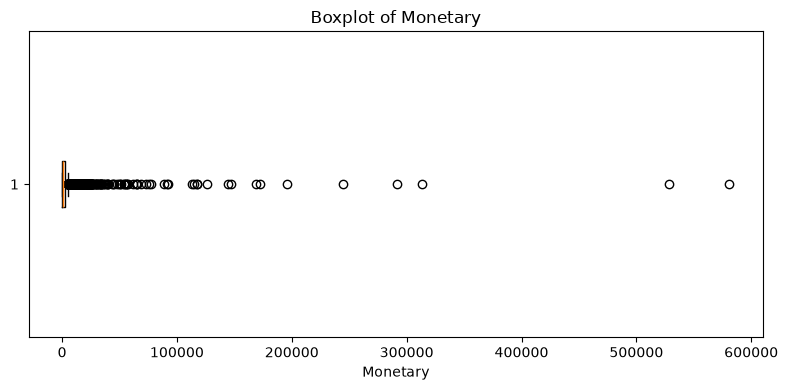

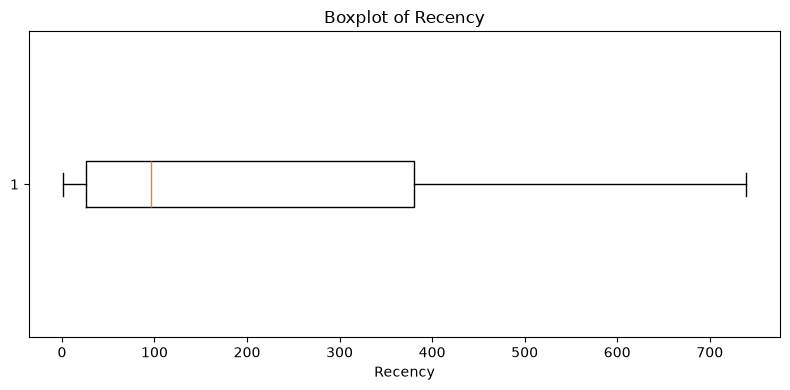

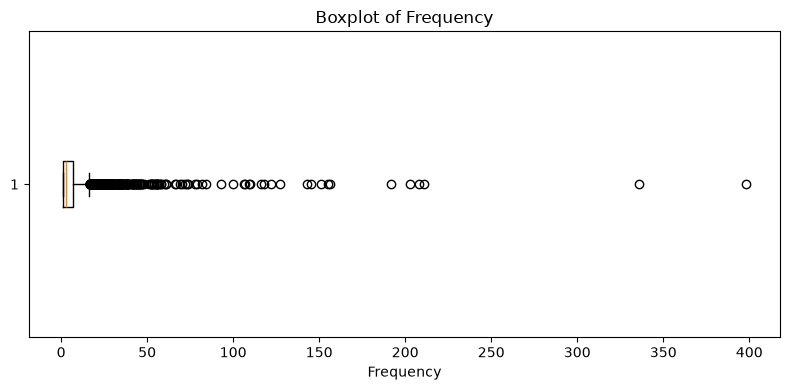

In [11]:
# Boxplots for Outlier Inspection.

for column in rfm_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(rfm[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column.title()}")
    plt.xlabel(column.title())
    plt.tight_layout()
    plt.show()

           monetary   recency  frequency
monetary   1.000000 -0.125016   0.627920
recency   -0.125016  1.000000  -0.257085
frequency  0.627920 -0.257085   1.000000


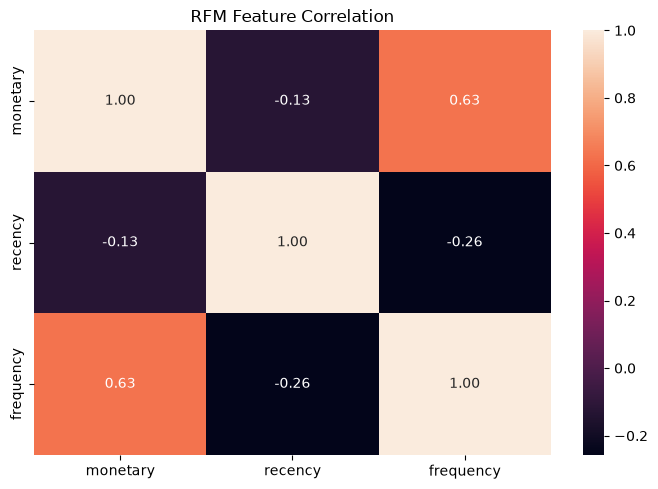

In [12]:
# RFM Correlation Analysis.

correlation = rfm[rfm_columns].corr()

print(correlation)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("RFM Feature Correlation")
plt.tight_layout()
plt.show()

In [13]:
# Create ML dataset

ml_data = rfm[[customer_id_col] + rfm_columns].copy()

print("ML dataset shape:", ml_data.shape)
ml_data.head()

ML dataset shape: (5878, 4)


,customer_id,monetary,recency,frequency
0,12346,77556.46,326,12
1,12347,4921.53,3,8
2,12348,2019.40,76,5
3,12349,4428.69,19,4
4,12350,334.40,311,1


In [14]:
# Check RFM skewness

print("RFM Skewness:")
print(ml_data[rfm_columns].skew().sort_values(ascending=False))

RFM Skewness:
monetary     25.070190
frequency    12.639951
recency       0.887194
dtype: float64


In [15]:
# Apply log transformation

rfm_log = ml_data[rfm_columns].copy()

for column in rfm_columns:
    rfm_log[column] = np.log1p(rfm_log[column])

print(rfm_log.head())

    monetary   recency  frequency
0  11.258774  5.789960   2.564949
1   8.501578  1.386294   2.197225
2   7.611051  4.343805   1.791759
3   8.396085  2.995732   1.609438
4   5.815324  5.743003   0.693147


In [16]:
# Check skewness after transformation

print("Skewness Before Transformation:")
print(ml_data[rfm_columns].skew())

print("\nSkewness After Log Transformation:")
print(rfm_log.skew())

Skewness Before Transformation:
monetary     25.070190
recency       0.887194
frequency    12.639951
dtype: float64

Skewness After Log Transformation:
monetary     0.269125
recency     -0.449106
frequency    1.001471
dtype: float64


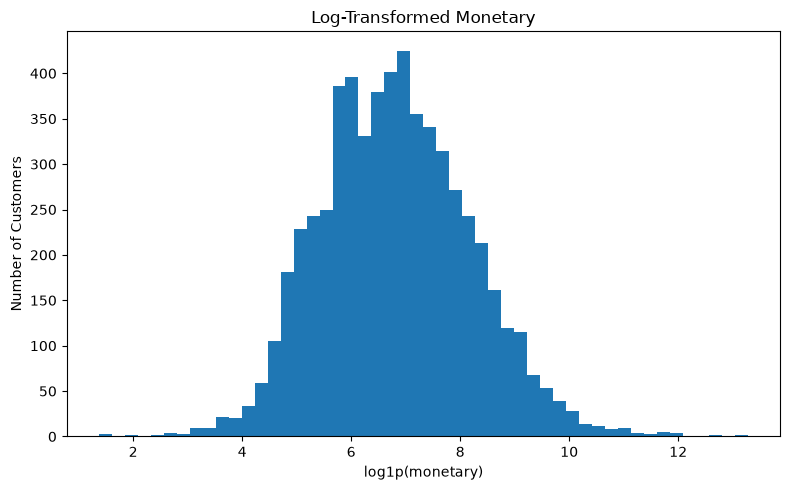

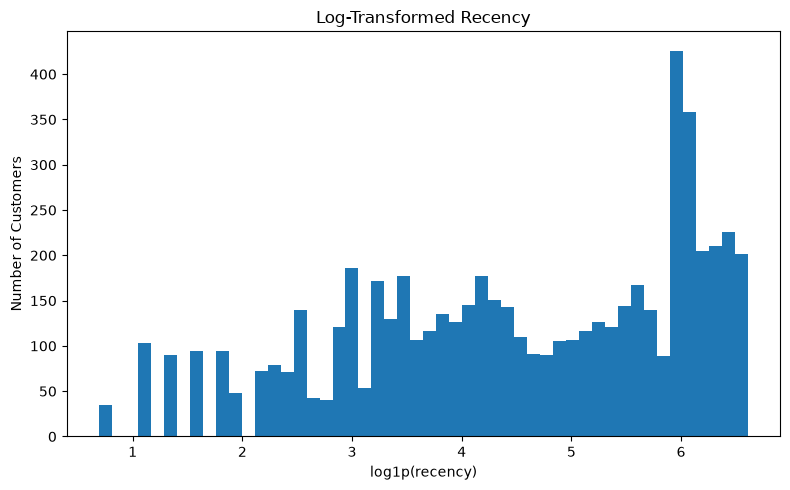

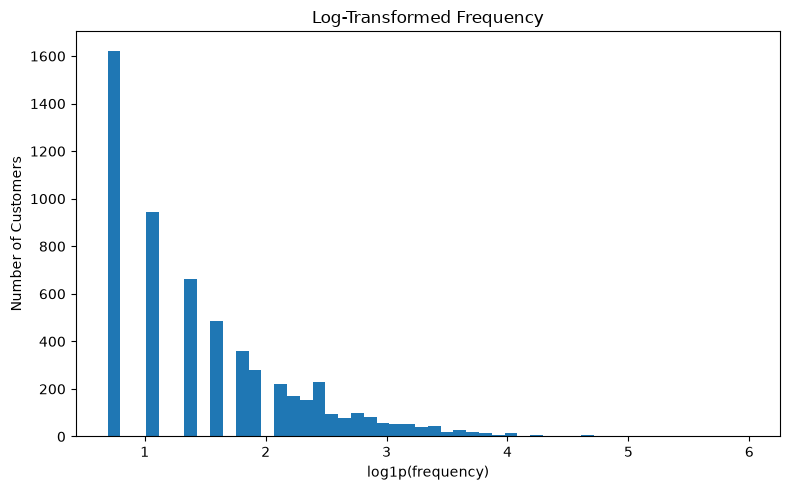

In [17]:
# Compare distributions before and after log transformation

for column in rfm_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(rfm_log[column], bins=50)
    plt.title(f"Log-Transformed {column.title()}")
    plt.xlabel(f"log1p({column})")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

In [18]:
# Standardize the features

scaler = StandardScaler()

X = scaler.fit_transform(rfm_log)

X = pd.DataFrame(
    X,
    columns=rfm_columns,
    index=ml_data.index
)

X.head()

,monetary,recency,frequency
0,3.206219,0.859687,1.254496
1,1.215993,-2.017050,0.800166
2,0.573185,-0.085028,0.299207
3,1.139846,-0.965670,0.073946
4,-0.723024,0.829011,-1.058146


In [19]:
# Verify Scaling

print("Means:")
print(X.mean())

print("\nStandard deviations:")
print(X.std())

Means:
monetary    -1.692344e-16
recency      8.703484e-17
frequency    2.381370e-16
dtype: float64

Standard deviations:
monetary     1.000085
recency      1.000085
frequency    1.000085
dtype: float64


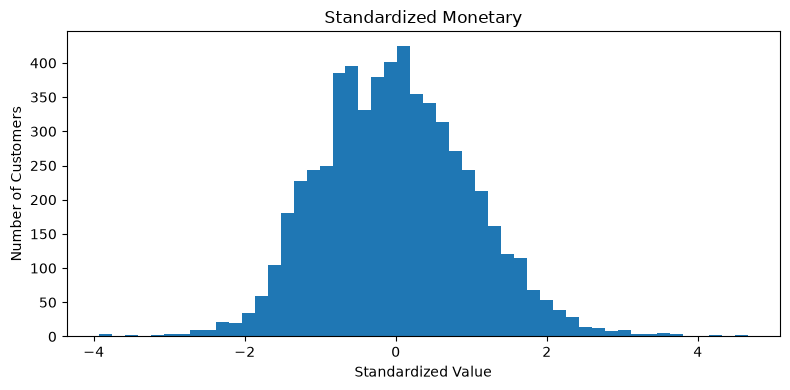

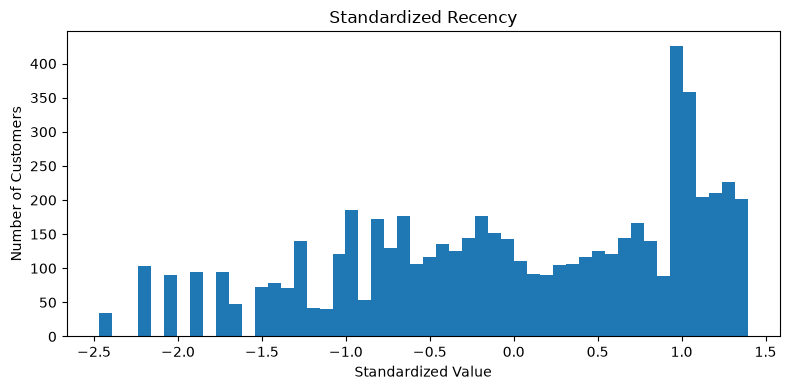

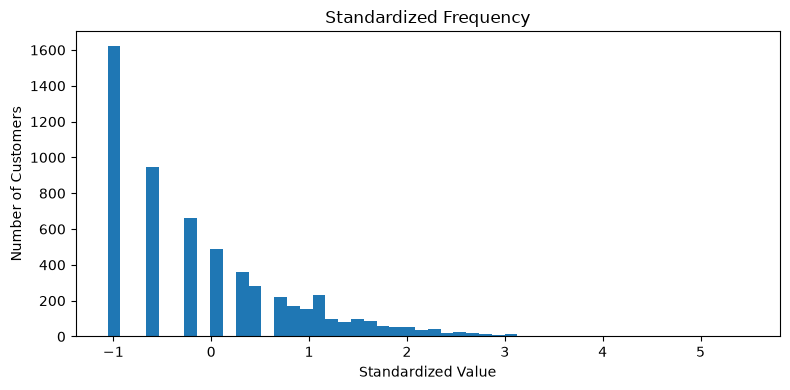

In [20]:
# Visualize standardized RFM

for column in rfm_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(X[column], bins=50)
    plt.title(f"Standardized {column.title()}")
    plt.xlabel("Standardized Value")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

In [21]:
# Create final ML Matrix

X_ml = X.copy()

print("Final ML matrix shape:", X_ml.shape)
print("\nFeatures:")
print(X_ml.columns.tolist())

Final ML matrix shape: (5878, 3)

Features:
['monetary', 'recency', 'frequency']


In [22]:
# Final preparation check.

print("Missing values:")
print(X_ml.isnull().sum())

print("\nInfinite values:")
print(np.isinf(X_ml).sum())

print("\nFinal shape:")
print(X_ml.shape)

Missing values:
monetary     0
recency      0
frequency    0
dtype: int64

Infinite values:
monetary     0
recency      0
frequency    0
dtype: int64

Final shape:
(5878, 3)


In [23]:
# Test different K-values -> use the elbow method to find the optimal number of clusters.

k_values = range(2, 11)

inertia_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_ml)
    inertia_values.append(model.inertia_) # inertia measures how closely customers within the same cluster are grouped together.

print("K values:", list(k_values))
print("Inertia values:", inertia_values)

K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertia values: [8577.106101879648, 6336.792062130816, 4895.413443680863, 4069.6258587099355, 3535.1144997135716, 3170.9199536620617, 2883.1159848933657, 2640.3987807953126, 2449.230097341669]


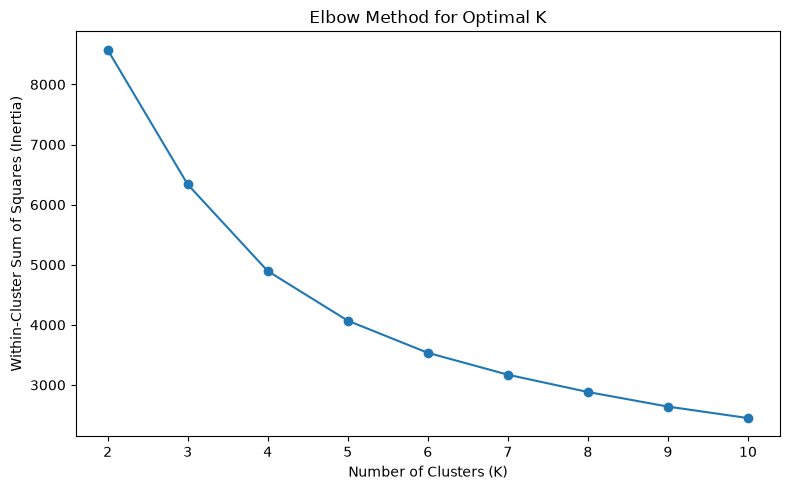

In [24]:
# Elbow Method -> Visualize the Inertia Values

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [25]:
# Calculate Silhouette Scores. -> measures how similar a customer is to its own cluster compared to other clusters. A higher score indicates better-defined clusters.

silhouette_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_ml)
    
    score = silhouette_score(
        X_ml,
        labels
    )
    
    silhouette_values.append(score)

print("Silhouette scores:")

for k, score in zip(k_values, silhouette_values):
    print(f"K={k}: {score:.4f}")

Silhouette scores:
K=2: 0.4385
K=3: 0.3479
K=4: 0.3664
K=5: 0.3440
K=6: 0.3348
K=7: 0.3029
K=8: 0.2957
K=9: 0.2884
K=10: 0.2899


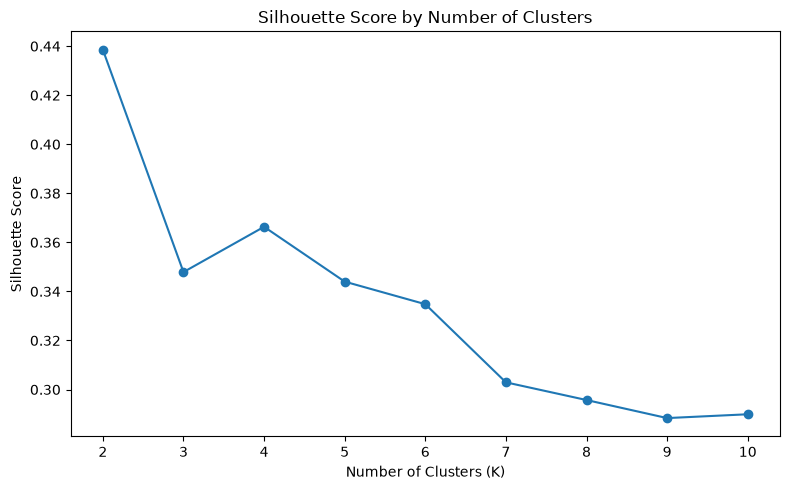

In [26]:
# Plot Silhouette Scores. -> Visualize the quality of the clustering.

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

In [27]:
# Create a comparison table. -> Compare the performance of different numbers of clusters.

cluster_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})

cluster_evaluation

,K,Inertia,Silhouette_Score
0,2,8577.106102,0.438543
1,3,6336.792062,0.347886
2,4,4895.413444,0.366353
3,5,4069.625859,0.343992
4,6,3535.114500,0.334793
5,7,3170.919954,0.302927
6,8,2883.115985,0.295711
7,9,2640.398781,0.288353
8,10,2449.230097,0.289906


In [28]:
# Find the highest Silhouette Score.

best_silhouette_k = cluster_evaluation.loc[
    cluster_evaluation["Silhouette_Score"].idxmax(),
    "K"
]

best_silhouette_score = cluster_evaluation["Silhouette_Score"].max()

print("Best K based on Silhouette Score:", int(best_silhouette_k))
print("Best Silhouette Score:", round(best_silhouette_score, 4))

Best K based on Silhouette Score: 2
Best Silhouette Score: 0.4385


In [29]:
# Show the top Candidates.

cluster_evaluation.sort_values(
    "Silhouette_Score",
    ascending=False
).head(5)

,K,Inertia,Silhouette_Score
0,2,8577.106102,0.438543
2,4,4895.413444,0.366353
1,3,6336.792062,0.347886
3,5,4069.625859,0.343992
4,6,3535.114500,0.334793


In [30]:
# Compare candidate K values.

candidate_k = cluster_evaluation[
    cluster_evaluation["K"].isin([2, 3, 4, 5])
].copy()

candidate_k

,K,Inertia,Silhouette_Score
0,2,8577.106102,0.438543
1,3,6336.792062,0.347886
2,4,4895.413444,0.366353
3,5,4069.625859,0.343992


In [31]:
# Temporarily fit K = 3

k3_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

k3_labels = k3_model.fit_predict(X_ml)

print("K=3 Silhouette Score:",
      round(silhouette_score(X_ml, k3_labels), 4))

K=3 Silhouette Score: 0.3479


In [32]:
# Temporarily fit K = 4

k4_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

k4_labels = k4_model.fit_predict(X_ml)

print("K=4 Silhouette Score:",
      round(silhouette_score(X_ml, k4_labels), 4))

K=4 Silhouette Score: 0.3664


In [33]:
# Compare cluster sizes

print("K=2 cluster sizes:")
print(pd.Series(
    KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    ).fit_predict(X_ml)
).value_counts().sort_index())

print("\nK=3 cluster sizes:")
print(pd.Series(k3_labels).value_counts().sort_index())

print("\nK=4 cluster sizes:")
print(pd.Series(k4_labels).value_counts().sort_index())

K=2 cluster sizes:
0    3546
1    2332
Name: count, dtype: int64

K=3 cluster sizes:
0    2260
1    1260
2    2358
Name: count, dtype: int64

K=4 cluster sizes:
0    1204
1    1455
2    1261
3    1958
Name: count, dtype: int64


In [34]:
# Final Model -> Based on the Silhouette Score and cluster sizes, K=2 is selected as the optimal number of clusters.

optimal_k = 2

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_ml)

print("Final K-Means model trained successfully.")
print("Number of clusters:", optimal_k)

Final K-Means model trained successfully.
Number of clusters: 2


In [35]:
# Add cluster labels to customer data

segmented_customers = rfm.copy()

segmented_customers["Cluster"] = cluster_labels

print("Customer segmentation completed.")
print("Rows:", len(segmented_customers))
print("Columns:", len(segmented_customers.columns))

Customer segmentation completed.
Rows: 5878
Columns: 8


In [36]:
# Check cluster Distribution.

cluster_counts = (
    segmented_customers["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    3546
1    2332
Name: count, dtype: int64

In [37]:
# Check cluster Distribution in percentage.

cluster_percentage = (
    segmented_customers["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_percentage

Cluster
0    60.326642
1    39.673358
Name: proportion, dtype: float64

In [38]:
# Create a cluster distribution table

cluster_summary = pd.DataFrame({
    "Customer_Count": cluster_counts,
    "Percentage": cluster_percentage.round(2)
})

cluster_summary

,Customer_Count,Percentage
Cluster,,
0,3546,60.33
1,2332,39.67


In [39]:
# Verify every customer received a cluster

print("Total customers:", len(segmented_customers))
print("Customers assigned to clusters:",
      segmented_customers["Cluster"].notna().sum())

print(
    "Unassigned customers:",
    segmented_customers["Cluster"].isna().sum()
)

Total customers: 5878
Customers assigned to clusters: 5878
Unassigned customers: 0


# Cluster Profiling & Business Segment Naming

In [40]:
# Create cluster profile. -> Analyze the characteristics of each cluster based on RFM metrics.

cluster_profile = (
    segmented_customers
    .groupby("Cluster")[rfm_columns]
    .agg(["count", "mean", "median", "min", "max"])
)

cluster_profile

monetary                                           recency  \
           count         mean    median     min        max   count   
Cluster                                                              
0           3546   611.554151   414.165    2.95   13916.34    3546   
1           2332  6520.683203  2852.505  252.49  580987.04    2332   

                                    frequency                             
               mean median min  max     count       mean median min  max  
Cluster                                                                   
0        301.052735  291.5   2  739      3546   2.094755    2.0   1   15  
1         51.046312   24.0   1  692      2332  12.667667    8.0   1  398

In [41]:
# Create a cleaner cluster summary with only mean and median values for RFM metrics.

cluster_rfm_summary = (
    segmented_customers
    .groupby("Cluster")[rfm_columns]
    .agg(["mean", "median"])
)

cluster_rfm_summary

monetary               recency         frequency       
                mean    median        mean median       mean median
Cluster                                                            
0         611.554151   414.165  301.052735  291.5   2.094755    2.0
1        6520.683203  2852.505   51.046312   24.0  12.667667    8.0

In [42]:
# Add customer counts

cluster_counts = (
    segmented_customers["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = cluster_rfm_summary.copy()

cluster_summary["Customer_Count"] = cluster_counts

cluster_summary

monetary               recency         frequency         \
                mean    median        mean median       mean median   
Cluster                                                               
0         611.554151   414.165  301.052735  291.5   2.094755    2.0   
1        6520.683203  2852.505   51.046312   24.0  12.667667    8.0   

        Customer_Count  
                        
Cluster                 
0                 3546  
1                 2332

In [43]:
# Create a simple profiling table.

profile = (
    segmented_customers
    .groupby("Cluster")
    .agg(
        Customer_Count=(customer_id_col, "nunique"),
        Avg_Recency=(rfm_columns[0], "mean"),
        Median_Recency=(rfm_columns[0], "median"),
        Avg_Frequency=(rfm_columns[1], "mean"),
        Median_Frequency=(rfm_columns[1], "median"),
        Avg_Monetary=(rfm_columns[2], "mean"),
        Median_Monetary=(rfm_columns[2], "median")
    )
)

profile.round(2)

,Customer_Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_Monetary,Median_Monetary
Cluster,,,,,,,
0,3546,611.55,414.16,301.05,291.5,2.09,2.0
1,2332,6520.68,2852.50,51.05,24.0,12.67,8.0


In [44]:
# Compare cluster Averages.

cluster_means = (
    segmented_customers
    .groupby("Cluster")[rfm_columns]
    .mean()
)

cluster_means.round(2)

,monetary,recency,frequency
Cluster,,,
0,611.55,301.05,2.09
1,6520.68,51.05,12.67


In [45]:
# Rank clusters by RFM

cluster_ranks = cluster_means.rank(
    ascending=[True, False, False]
)

cluster_ranks

,monetary,recency,frequency
Cluster,,,
0,1.0,2.0,1.0
1,2.0,1.0,2.0


<Figure size 800x500 with 0 Axes>

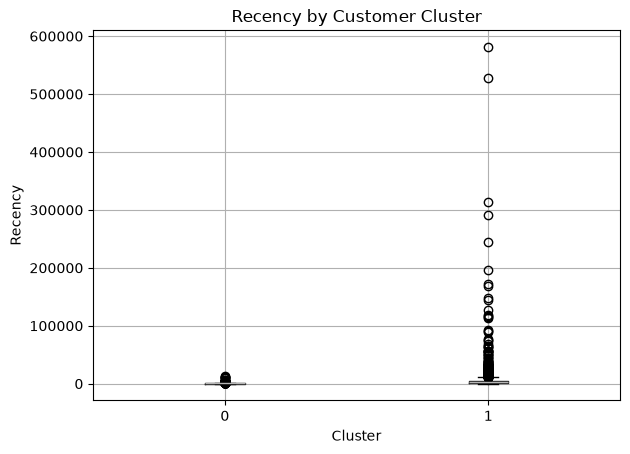

In [46]:
# Visualize RFM by cluster for Recency

plt.figure(figsize=(8, 5))

segmented_customers.boxplot(
    column=rfm_columns[0],
    by="Cluster"
)

plt.title("Recency by Customer Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Recency")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

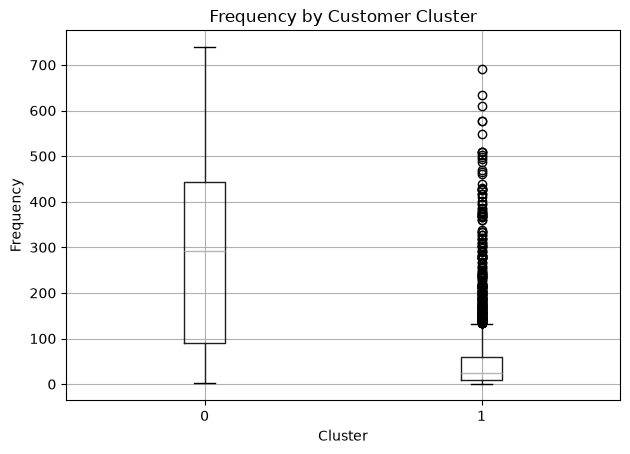

In [47]:
# Visualize RFM by cluster for Recency

plt.figure(figsize=(8, 5))

segmented_customers.boxplot(
    column=rfm_columns[1],
    by="Cluster"
)

plt.title("Frequency by Customer Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

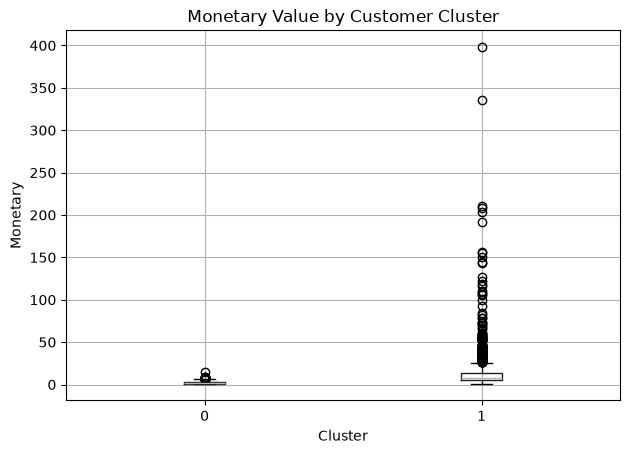

In [48]:
# Visualize RFM by cluster for Monetary

plt.figure(figsize=(8, 5))

segmented_customers.boxplot(
    column=rfm_columns[2],
    by="Cluster"
)

plt.title("Monetary Value by Customer Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Monetary")
plt.tight_layout()
plt.show()

In [49]:
# Calculate overall averages.

overall_rfm = segmented_customers[rfm_columns].mean()

overall_rfm

monetary     2955.904092
recency       201.866791
frequency       6.289384
dtype: float64

In [50]:
# Calculate cluster performance relative to overall average

cluster_vs_overall = cluster_means / overall_rfm

cluster_vs_overall.round(2)

,monetary,recency,frequency
Cluster,,,
0,0.21,1.49,0.33
1,2.21,0.25,2.01


In [51]:
# Create a business interpretation helper

for cluster in cluster_means.index:
    print(f"\nCluster {cluster}")
    print("-" * 30)
    
    for feature in rfm_columns:
        value = cluster_means.loc[cluster, feature]
        overall = overall_rfm[feature]
        ratio = value / overall
        
        print(
            f"{feature}: {value:.2f} "
            f"({ratio:.2f}x overall average)"
        )


Cluster 0
------------------------------
monetary: 611.55 (0.21x overall average)
recency: 301.05 (1.49x overall average)
frequency: 2.09 (0.33x overall average)

Cluster 1
------------------------------
monetary: 6520.68 (2.21x overall average)
recency: 51.05 (0.25x overall average)
frequency: 12.67 (2.01x overall average)


In [52]:


print("CUSTOMER CLUSTER PROFILE")
print("=" * 60)

for cluster in cluster_means.index:
    print(f"\nCluster {cluster}")
    print("-" * 30)
    
    for feature in rfm_columns:
        print(
            f"{feature.title()}: "
            f"{cluster_means.loc[cluster, feature]:.2f}"
        )
        
    print(
        f"Customers: "
        f"{cluster_counts.loc[cluster]:,}"
    )

CUSTOMER CLUSTER PROFILE

Cluster 0
------------------------------
Monetary: 611.55
Recency: 301.05
Frequency: 2.09
Customers: 3,546

Cluster 1
------------------------------
Monetary: 6520.68
Recency: 51.05
Frequency: 12.67
Customers: 2,332


# Create Business Segment Labels

In [53]:
# Map clusters to business segments

segment_mapping = {
    0: "At-Risk / Inactive Customers",
    1: "High-Value Loyal Customers"
}

segmented_customers["Segment"] = (
    segmented_customers["Cluster"]
    .map(segment_mapping)
)

segmented_customers.head()

,customer_key,customer_id,country,last_purchase_date,recency,frequency,monetary,Cluster,Segment
0,1,12346,United Kingdom,2011-01-18,326,12,77556.46,1,High-Value Loyal Customers
1,2,12347,Iceland,2011-12-07,3,8,4921.53,1,High-Value Loyal Customers
2,3,12348,Finland,2011-09-25,76,5,2019.40,1,High-Value Loyal Customers
3,4,12349,Italy,2011-11-21,19,4,4428.69,1,High-Value Loyal Customers
4,5,12350,Norway,2011-02-02,311,1,334.40,0,At-Risk / Inactive Customers


In [54]:
# Verify the segment assignment

segmented_customers[
    ["Cluster", "Segment"]
].drop_duplicates().sort_values("Cluster")

,Cluster,Segment
4,0,At-Risk / Inactive Customers
0,1,High-Value Loyal Customers


In [55]:
# Segment distribution

segment_distribution = (
    segmented_customers["Segment"]
    .value_counts()
    .rename_axis("Segment")
    .reset_index(name="Customer_Count")
)

segment_distribution["Percentage"] = (
    segment_distribution["Customer_Count"]
    / len(segmented_customers)
    * 100
).round(2)

segment_distribution

,Segment,Customer_Count,Percentage
0,At-Risk / Inactive Customers,3546,60.33
1,High-Value Loyal Customers,2332,39.67


In [56]:
# Final business segment profile

final_segment_profile = (
    segmented_customers
    .groupby("Segment")
    .agg(
        Customer_Count=(customer_id_col, "nunique"),
        Avg_Recency=(rfm_columns[0], "mean"),
        Avg_Frequency=(rfm_columns[1], "mean"),
        Avg_Monetary=(rfm_columns[2], "mean")
    )
    .reset_index()
)

final_segment_profile.round(2)

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At-Risk / Inactive Customers,3546,611.55,301.05,2.09
1,High-Value Loyal Customers,2332,6520.68,51.05,12.67


In [57]:
# Sort segments by customer value

final_segment_profile = final_segment_profile.sort_values(
    "Avg_Monetary",
    ascending=False
).reset_index(drop=True)

final_segment_profile.round(2)

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,High-Value Loyal Customers,2332,6520.68,51.05,12.67
1,At-Risk / Inactive Customers,3546,611.55,301.05,2.09


In [58]:
# Validate the final segmentation

print("Total customers:", len(segmented_customers))
print(
    "Customers with segments:",
    segmented_customers["Segment"].notna().sum()
)
print(
    "Customers without segments:",
    segmented_customers["Segment"].isna().sum()
)
print(
    "Number of segments:",
    segmented_customers["Segment"].nunique()
)

Total customers: 5878
Customers with segments: 5878
Customers without segments: 0
Number of segments: 2


In [59]:
# Business recommendations

segment_strategy = {
    "At-Risk / Inactive Customers": {
        "Profile": "Low recency, low frequency and low monetary value",
        "Strategy": "Re-engagement campaigns, personalized offers and win-back promotions"
    },
    "High-Value Loyal Customers": {
        "Profile": "Recent purchases, high purchase frequency and high monetary value",
        "Strategy": "VIP rewards, loyalty benefits, cross-selling and retention campaigns"
    }
}

for segment, details in segment_strategy.items():
    print(f"\n{segment}")
    print(f"Profile: {details['Profile']}")
    print(f"Strategy: {details['Strategy']}")


At-Risk / Inactive Customers
Profile: Low recency, low frequency and low monetary value
Strategy: Re-engagement campaigns, personalized offers and win-back promotions

High-Value Loyal Customers
Profile: Recent purchases, high purchase frequency and high monetary value
Strategy: VIP rewards, loyalty benefits, cross-selling and retention campaigns


In [60]:
# Apply PCA(principal component analysis) for dimensionality reduction and visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_ml)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=segmented_customers.index
)

pca_df["Cluster"] = segmented_customers["Cluster"]
pca_df["Segment"] = segmented_customers["Segment"]

pca_df.head()

,PC1,PC2,Cluster,Segment
0,2.275506,2.442792,1,High-Value Loyal Customers
1,2.246181,-0.991572,1,High-Value Loyal Customers
2,0.573559,0.253765,1,High-Value Loyal Customers
3,1.221335,-0.335379,1,High-Value Loyal Customers
4,-1.507872,0.097815,0,At-Risk / Inactive Customers


In [61]:
# Check Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

print("PC1 explained variance:",
      round(explained_variance[0] * 100, 2), "%")

print("PC2 explained variance:",
      round(explained_variance[1] * 100, 2), "%")

print(
    "Total explained variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

PC1 explained variance: 76.39 %
PC2 explained variance: 18.71 %
Total explained variance: 95.1 %


In [62]:
# PCA Component loadings -> represent the contribution of each original feature to the principal components. This helps in understanding which features are most influential in defining the clusters.

pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=rfm_columns
)

pca_loadings.round(3)

,PC1,PC2
monetary,0.604,0.415
recency,-0.505,0.860
frequency,0.617,0.298


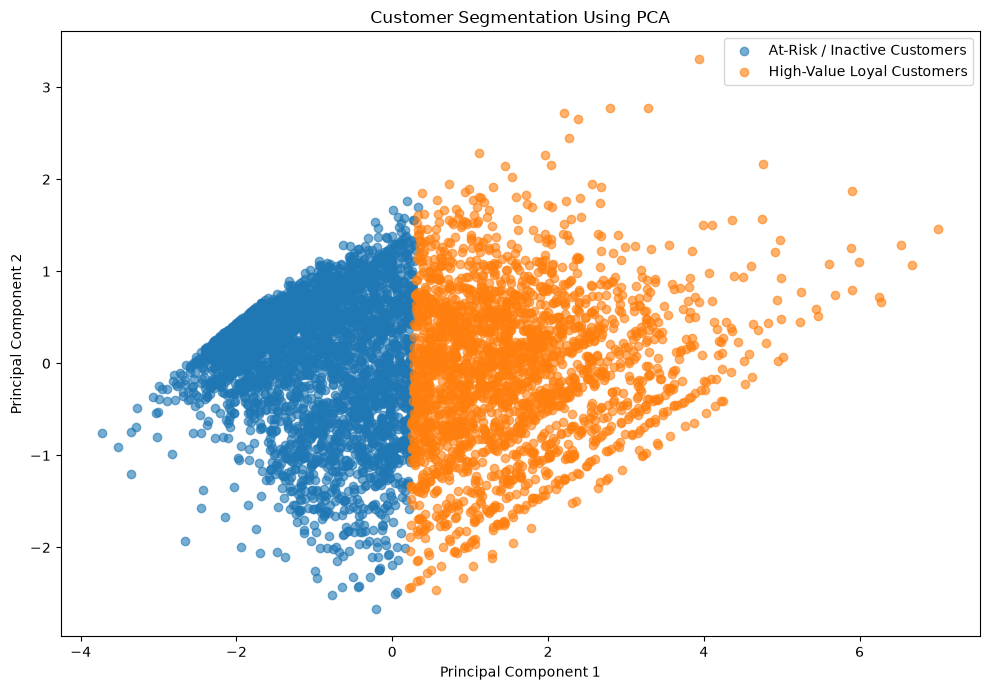

In [63]:
# PCA cluster visualization

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=cluster_data["Segment"].iloc[0],
        alpha=0.6
    )

plt.title("Customer Segmentation Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

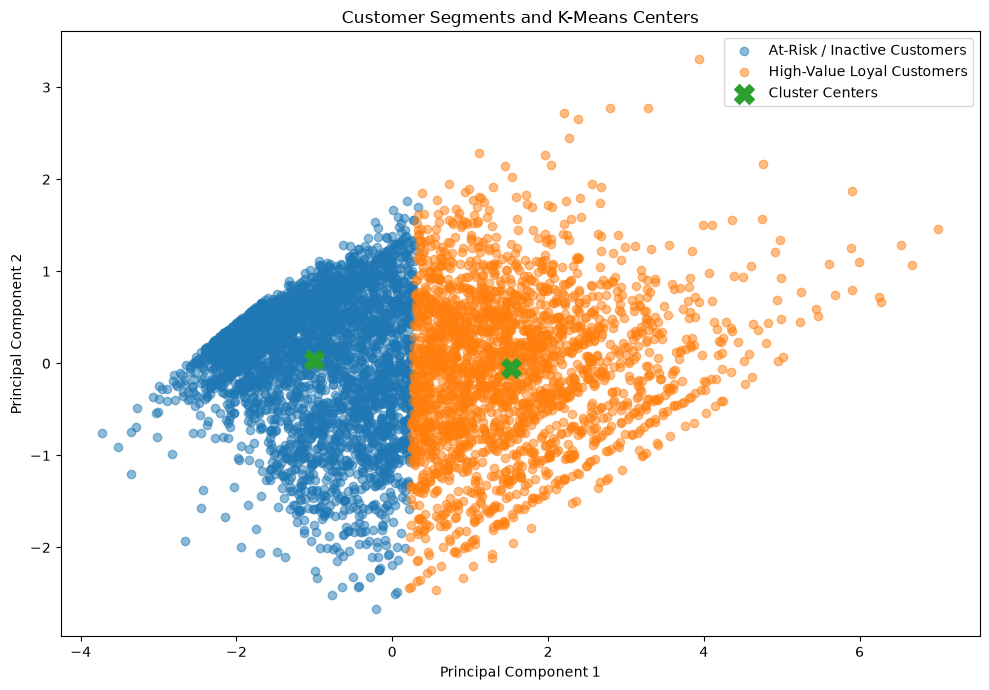

In [64]:
# Visualize cluster centers in PCA space

cluster_centers_pca = pca.transform(
    kmeans.cluster_centers_
)

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=cluster_data["Segment"].iloc[0],
        alpha=0.5
    )

plt.scatter(
    cluster_centers_pca[:, 0],
    cluster_centers_pca[:, 1],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.title("Customer Segments and K-Means Centers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

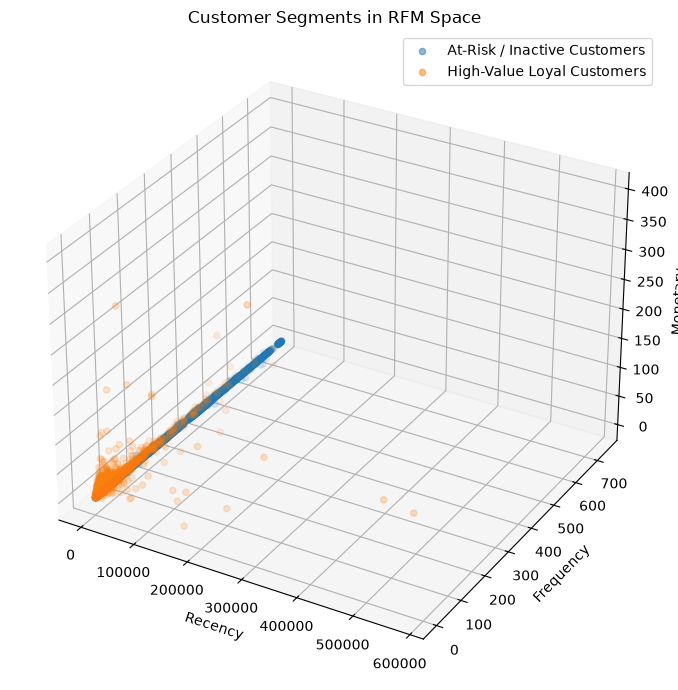

In [65]:
# 3D RFM perspective

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

for cluster in sorted(segmented_customers["Cluster"].unique()):
    
    cluster_data = segmented_customers[
        segmented_customers["Cluster"] == cluster
    ]
    
    ax.scatter(
        cluster_data[rfm_columns[0]],
        cluster_data[rfm_columns[1]],
        cluster_data[rfm_columns[2]],
        label=cluster_data["Segment"].iloc[0],
        alpha=0.5
    )

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

ax.set_title("Customer Segments in RFM Space")
ax.legend()

plt.tight_layout()
plt.show()

In [66]:
# Calculate cluster separation again

final_silhouette = silhouette_score(
    X_ml,
    segmented_customers["Cluster"]
)

print(
    "Final K-Means Silhouette Score:",
    round(final_silhouette, 4)
)

Final K-Means Silhouette Score: 0.4385


In [68]:
# Final ML Modle Summary.

model_summary = pd.DataFrame({
    "Metric": [
        "Number of Customers",
        "Number of RFM Features",
        "Number of Clusters",
        "Silhouette Score",
        "PCA Components"
    ],
    "Value": [
        len(segmented_customers),
        len(rfm_columns),
        optimal_k,
        round(final_silhouette, 4),
        2
    ]
})

model_summary

,Metric,Value
0,Number of Customers,5878.0000
1,Number of RFM Features,3.0000
2,Number of Clusters,2.0000
3,Silhouette Score,0.4385
4,PCA Components,2.0000


In [ ]:
# Inspect the final segmented customers dataset

segmented_customers.head()

,customer_key,customer_id,country,last_purchase_date,recency,frequency,monetary,Cluster,Segment
0,1,12346,United Kingdom,2011-01-18,326,12,77556.46,1,High-Value Loyal Customers
1,2,12347,Iceland,2011-12-07,3,8,4921.53,1,High-Value Loyal Customers
2,3,12348,Finland,2011-09-25,76,5,2019.40,1,High-Value Loyal Customers
3,4,12349,Italy,2011-11-21,19,4,4428.69,1,High-Value Loyal Customers
4,5,12350,Norway,2011-02-02,311,1,334.40,0,At-Risk / Inactive Customers


In [71]:
# Check the columns in the final segmented customers dataset

print("Columns:")
for column in segmented_customers.columns:
    print("→", column)

Columns:
→ customer_key
→ customer_id
→ country
→ last_purchase_date
→ recency
→ frequency
→ monetary
→ Cluster
→ Segment


In [72]:
# Check final dataset dimensions.

print("Rows:", segmented_customers.shape[0])
print("Columns:", segmented_customers.shape[1])

Rows: 5878
Columns: 9


In [73]:
# Check final data quality

print("Missing values:")
print(segmented_customers.isnull().sum())

print("\nDuplicate rows:")
print(segmented_customers.duplicated().sum())

print("\nDuplicate customers:")
print(
    segmented_customers[customer_id_col]
    .duplicated()
    .sum()
)

Missing values:
customer_key          0
customer_id           0
country               0
last_purchase_date    0
recency               0
frequency             0
monetary              0
Cluster               0
Segment               0
dtype: int64

Duplicate rows:
0

Duplicate customers:
0


In [74]:
# Create the final customer segmentation dataset

final_customer_segmentation = segmented_customers.copy()

print(
    "Final customer segmentation dataset created:",
    final_customer_segmentation.shape
)

Final customer segmentation dataset created: (5878, 9)


In [75]:
# Arrange important columns first(to the front) for better readability and analysis.

priority_columns = [
    customer_id_col,
    *rfm_columns,
    "Cluster",
    "Segment"
]

remaining_columns = [
    column
    for column in final_customer_segmentation.columns
    if column not in priority_columns
]

final_customer_segmentation = final_customer_segmentation[
    priority_columns + remaining_columns
]

final_customer_segmentation.head()

,customer_id,monetary,recency,frequency,Cluster,Segment,customer_key,country,last_purchase_date
0,12346,77556.46,326,12,1,High-Value Loyal Customers,1,United Kingdom,2011-01-18
1,12347,4921.53,3,8,1,High-Value Loyal Customers,2,Iceland,2011-12-07
2,12348,2019.40,76,5,1,High-Value Loyal Customers,3,Finland,2011-09-25
3,12349,4428.69,19,4,1,High-Value Loyal Customers,4,Italy,2011-11-21
4,12350,334.40,311,1,0,At-Risk / Inactive Customers,5,Norway,2011-02-02


In [76]:
# Create a segment summary dataset

segment_summary = (
    final_customer_segmentation
    .groupby("Segment")
    .agg(
        Customer_Count=(customer_id_col, "nunique"),
        Avg_Recency=(rfm_columns[0], "mean"),
        Avg_Frequency=(rfm_columns[1], "mean"),
        Avg_Monetary=(rfm_columns[2], "mean")
    )
    .reset_index()
)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customer_Count"]
    / segment_summary["Customer_Count"].sum()
    * 100
).round(2)

segment_summary = segment_summary.round({
    "Avg_Recency": 2,
    "Avg_Frequency": 2,
    "Avg_Monetary": 2
})

segment_summary

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
0,At-Risk / Inactive Customers,3546,611.55,301.05,2.09,60.33
1,High-Value Loyal Customers,2332,6520.68,51.05,12.67,39.67


In [77]:
# Verify segment total.

print(
    "Total customers:",
    final_customer_segmentation[customer_id_col].nunique()
)

print(
    "Total segmented customers:",
    final_customer_segmentation["Segment"].notna().sum()
)

print(
    "Unsegmented customers:",
    final_customer_segmentation["Segment"].isna().sum()
)

Total customers: 5878
Total segmented customers: 5878
Unsegmented customers: 0


In [78]:
# Export the customer segmentation dataset

from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

print("Output folder ready:", output_dir.resolve())

Output folder ready: E:\Github Repos\Customer Segmentation Project\outputs


In [79]:
# Now export the main dataset

customer_output_path = output_dir / "customer_segmentation.csv"

final_customer_segmentation.to_csv(
    customer_output_path,
    index=False
)

print(
    "Customer segmentation exported to:",
    customer_output_path
)

Customer segmentation exported to: outputs\customer_segmentation.csv


In [80]:
# Export the segment summary dataset

summary_output_path = output_dir / "segment_summary.csv"

segment_summary.to_csv(
    summary_output_path,
    index=False
)

print(
    "Segment summary exported to:",
    summary_output_path
)

Segment summary exported to: outputs\segment_summary.csv


In [81]:
# Verify the exported customer segmentation dataset

verification = pd.read_csv(customer_output_path)

print("Export verification successful.")
print("Rows:", verification.shape[0])
print("Columns:", verification.shape[1])

verification.head()

Export verification successful.
Rows: 5878
Columns: 9


,customer_id,monetary,recency,frequency,Cluster,Segment,customer_key,country,last_purchase_date
0,12346,77556.46,326,12,1,High-Value Loyal Customers,1,United Kingdom,2011-01-18
1,12347,4921.53,3,8,1,High-Value Loyal Customers,2,Iceland,2011-12-07
2,12348,2019.40,76,5,1,High-Value Loyal Customers,3,Finland,2011-09-25
3,12349,4428.69,19,4,1,High-Value Loyal Customers,4,Italy,2011-11-21
4,12350,334.40,311,1,0,At-Risk / Inactive Customers,5,Norway,2011-02-02


In [82]:
# Verify the exported segments

verification["Segment"].value_counts()

Segment
At-Risk / Inactive Customers    3546
High-Value Loyal Customers      2332
Name: count, dtype: int64

In [83]:
# Final ML Output check

print("FINAL CUSTOMER SEGMENTATION")
print("=" * 50)

print("Customers:", len(final_customer_segmentation))
print("Features:", len(rfm_columns))
print("Clusters:", optimal_k)
print("Silhouette Score:", round(final_silhouette, 4))

print("\nSegments:")
print(
    final_customer_segmentation["Segment"]
    .value_counts()
)

print("\nOutput file:")
print(customer_output_path)

FINAL CUSTOMER SEGMENTATION
Customers: 5878
Features: 3
Clusters: 2
Silhouette Score: 0.4385

Segments:
Segment
At-Risk / Inactive Customers    3546
High-Value Loyal Customers      2332
Name: count, dtype: int64

Output file:
outputs\customer_segmentation.csv


# Save the ML Model & Final Validation

In [84]:
# Import joblib and json for model serialization and configuration saving

import joblib
import json

In [85]:
# Create model output folder.

model_dir = output_dir / "model"
model_dir.mkdir(exist_ok=True)

print("Model folder ready:", model_dir.resolve())

Model folder ready: E:\Github Repos\Customer Segmentation Project\outputs\model


In [86]:
# Save the KMeans model using joblib

kmeans_path = model_dir / "kmeans_customer_segmentation.joblib"

joblib.dump(
    kmeans,
    kmeans_path
)

print("K-Means model saved:")
print(kmeans_path)

K-Means model saved:
outputs\model\kmeans_customer_segmentation.joblib


In [87]:
# Save the scaler used for feature standardization using joblib.

scaler_path = model_dir / "rfm_scaler.joblib"

joblib.dump(
    scaler,
    scaler_path
)

print("Scaler saved:")
print(scaler_path)

Scaler saved:
outputs\model\rfm_scaler.joblib


In [88]:
# Save the PCA model using joblib. -> used for dimensionality reduction and visualization.

pca_path = model_dir / "rfm_pca.joblib"

joblib.dump(
    pca,
    pca_path
)

print("PCA model saved:")
print(pca_path)

PCA model saved:
outputs\model\rfm_pca.joblib


In [89]:
# Save RFM configuration

model_config = {
    "rfm_columns": rfm_columns,
    "customer_id_column": customer_id_col,
    "optimal_k": int(optimal_k),
    "silhouette_score": float(final_silhouette),
    "transformation": "log1p",
    "scaling": "StandardScaler"
}

config_path = model_dir / "model_config.json"

with open(config_path, "w") as file:
    json.dump(
        model_config,
        file,
        indent=4
    )

print("Model configuration saved:")
print(config_path)

Model configuration saved:
outputs\model\model_config.json


In [90]:
# Save segment mapping for business interpretation

segment_mapping_path = model_dir / "segment_mapping.json"

with open(segment_mapping_path, "w") as file:
    json.dump(
        {
            str(key): value
            for key, value in segment_mapping.items()
        },
        file,
        indent=4
    )

print("Segment mapping saved:")
print(segment_mapping_path)

Segment mapping saved:
outputs\model\segment_mapping.json


In [91]:
# List all save model files in the model directory.

for file in model_dir.iterdir():
    print(file.name)

kmeans_customer_segmentation.joblib
model_config.json
rfm_pca.joblib
rfm_scaler.joblib
segment_mapping.json


In [92]:
# Test model loading

loaded_kmeans = joblib.load(
    kmeans_path
)

loaded_scaler = joblib.load(
    scaler_path
)

loaded_pca = joblib.load(
    pca_path
)

print("All ML objects loaded successfully.")

All ML objects loaded successfully.


In [93]:
# Reproduce predictions for a sample of customers using the loaded models.

X_reloaded = ml_data[rfm_columns].copy()

for column in rfm_columns:
    X_reloaded[column] = np.log1p(
        X_reloaded[column]
    )

X_reloaded = loaded_scaler.transform(
    X_reloaded
)

reloaded_predictions = loaded_kmeans.predict(
    X_reloaded
)

print(
    "Predictions reproduced:",
    len(reloaded_predictions)
)

Predictions reproduced: 5878


In [94]:
# Verify predictions match

predictions_match = np.array_equal(
    reloaded_predictions,
    segmented_customers["Cluster"].values
)

print(
    "Saved model reproduces original predictions:",
    predictions_match
)

Saved model reproduces original predictions: True


In [95]:
# Final model validation.

validation_results = {
    "Customers": len(segmented_customers),
    "RFM Features": len(rfm_columns),
    "Clusters": optimal_k,
    "Silhouette Score": round(final_silhouette, 4),
    "Missing Segments": int(
        segmented_customers["Segment"].isna().sum()
    ),
    "Duplicate Customers": int(
        segmented_customers[customer_id_col].duplicated().sum()
    ),
    "Predictions Reproduced": predictions_match
}

for metric, value in validation_results.items():
    print(f"{metric}: {value}")

Customers: 5878
RFM Features: 3
Clusters: 2
Silhouette Score: 0.4385
Missing Segments: 0
Duplicate Customers: 0
Predictions Reproduced: True


In [96]:
# Save final model report.

model_validation_path = output_dir / "model_validation.csv"

pd.DataFrame(
    list(validation_results.items()),
    columns=["Metric", "Value"]
).to_csv(
    model_validation_path,
    index=False
)

print("Model validation report saved:")
print(model_validation_path)

Model validation report saved:
outputs\model_validation.csv


In [97]:
# Final ML project Summary.

print("=" * 60)
print("CUSTOMER SEGMENTATION — FINAL ML SUMMARY")
print("=" * 60)

print(f"Customers: {len(segmented_customers):,}")
print(f"RFM Features: {len(rfm_columns)}")
print(f"Optimal K: {optimal_k}")
print(f"Silhouette Score: {final_silhouette:.4f}")

print("\nCustomer Segments:")
for segment, count in (
    segmented_customers["Segment"]
    .value_counts()
    .items()
):
    percentage = count / len(segmented_customers) * 100
    print(
        f"- {segment}: "
        f"{count:,} customers "
        f"({percentage:.2f}%)"
    )

print("\nModel validation:")
print(f"- Missing segments: {segmented_customers['Segment'].isna().sum()}")
print(
    f"- Duplicate customers: "
    f"{segmented_customers[customer_id_col].duplicated().sum()}"
)
print(
    f"- Predictions reproduced: "
    f"{predictions_match}"
)

CUSTOMER SEGMENTATION — FINAL ML SUMMARY
Customers: 5,878
RFM Features: 3
Optimal K: 2
Silhouette Score: 0.4385

Customer Segments:
- At-Risk / Inactive Customers: 3,546 customers (60.33%)
- High-Value Loyal Customers: 2,332 customers (39.67%)

Model validation:
- Missing segments: 0
- Duplicate customers: 0
- Predictions reproduced: True


# Load ML Segments Back into PostgreSQL

In [ ]:
# Prepare PostgreSQL dataset

segment_upload = final_customer_segmentation[
    [
        customer_id_col,
        "monetary",
        "recency",
        "frequency",
        "Cluster",
        "Segment"
    ]
].copy()

segment_upload = segment_upload.rename(
    columns={
        customer_id_col: "customer_id",
        "Cluster": "cluster",
        "Segment": "segment"
    }
)

segment_upload = segment_upload[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "cluster",
        "segment"
    ]
]

segment_upload.head()

,customer_id,recency,frequency,monetary,cluster,segment
0,12346,326,12,77556.46,1,High-Value Loyal Customers
1,12347,3,8,4921.53,1,High-Value Loyal Customers
2,12348,76,5,2019.40,1,High-Value Loyal Customers
3,12349,19,4,4428.69,1,High-Value Loyal Customers
4,12350,311,1,334.40,0,At-Risk / Inactive Customers


In [101]:
# now check the segmented data

print("Rows:", len(segment_upload))
print("Columns:", segment_upload.columns.tolist())

Rows: 5878
Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'cluster', 'segment']


In [108]:
# Load into PostgreSql, upload segmentation data.

segment_upload.to_sql(
    "customer_segments",
    engine,
    schema="warehouse",
    if_exists="append",
    index=False
)

print("Corrected customer segmentation loaded successfully.")

Corrected customer segmentation loaded successfully.
